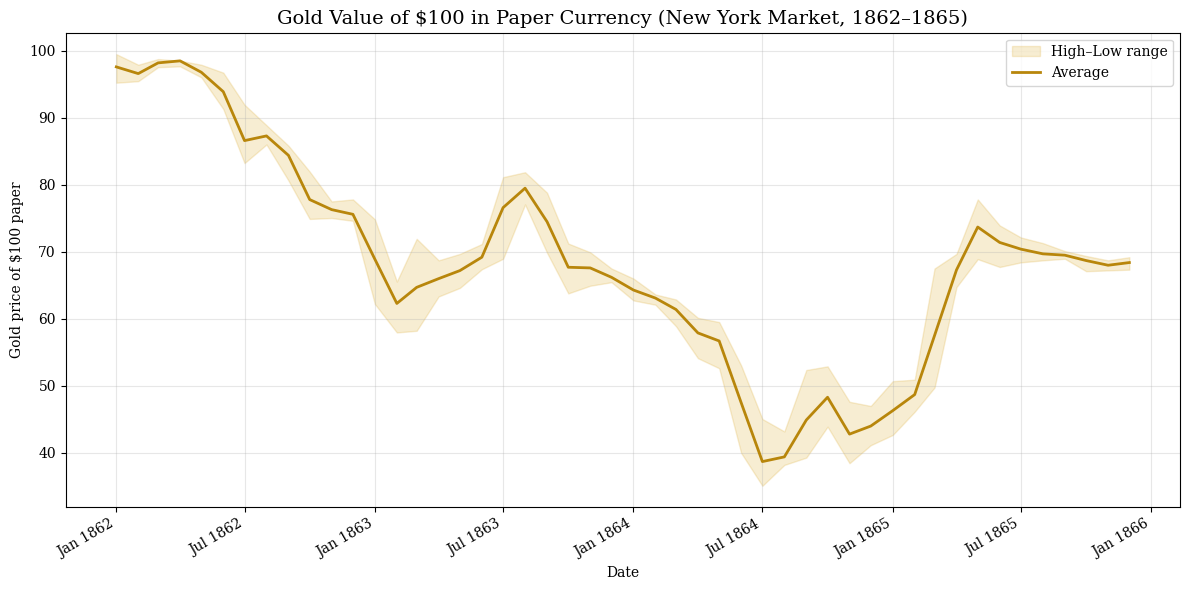

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv("data/mitchell_table1_gold_prices_1862_1865.csv", comment="#")
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"], format="%Y-%B")

fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(df["date"], df["lowest"], df["highest"], alpha=0.2, color="goldenrod", label="High–Low range")
ax.plot(df["date"], df["average"], color="darkgoldenrod", linewidth=2, label="Average")

ax.set_title("Gold Value of $100 in Paper Currency (New York Market, 1862–1865)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Gold price of $100 paper")
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

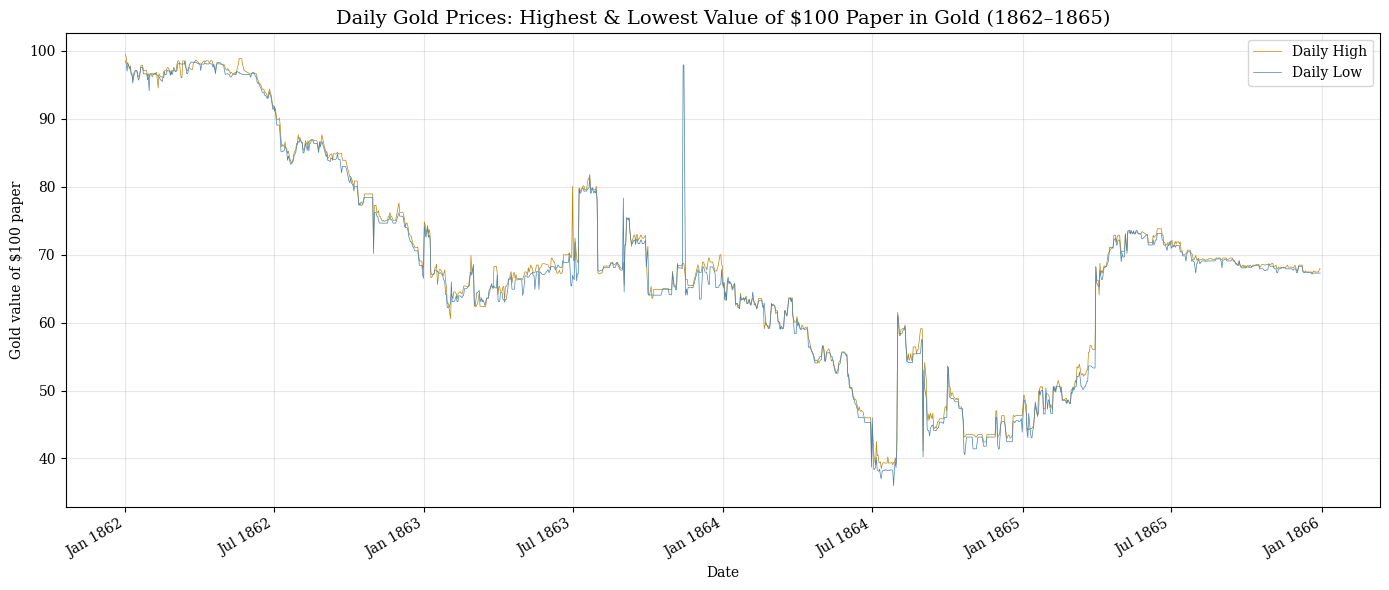

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv("data/mitchell_appendix_a_table2_daily_gold_prices.csv", comment="#")
df["date"] = pd.to_datetime(df[["year", "month", "day"]])

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df["date"], df["highest"], color="darkgoldenrod", linewidth=0.5, label="Daily High")
ax.plot(df["date"], df["lowest"], color="steelblue", linewidth=0.5, label="Daily Low")

ax.set_title("Daily Gold Prices: Highest & Lowest Value of $100 Paper in Gold (1862–1865)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Gold value of $100 paper")
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

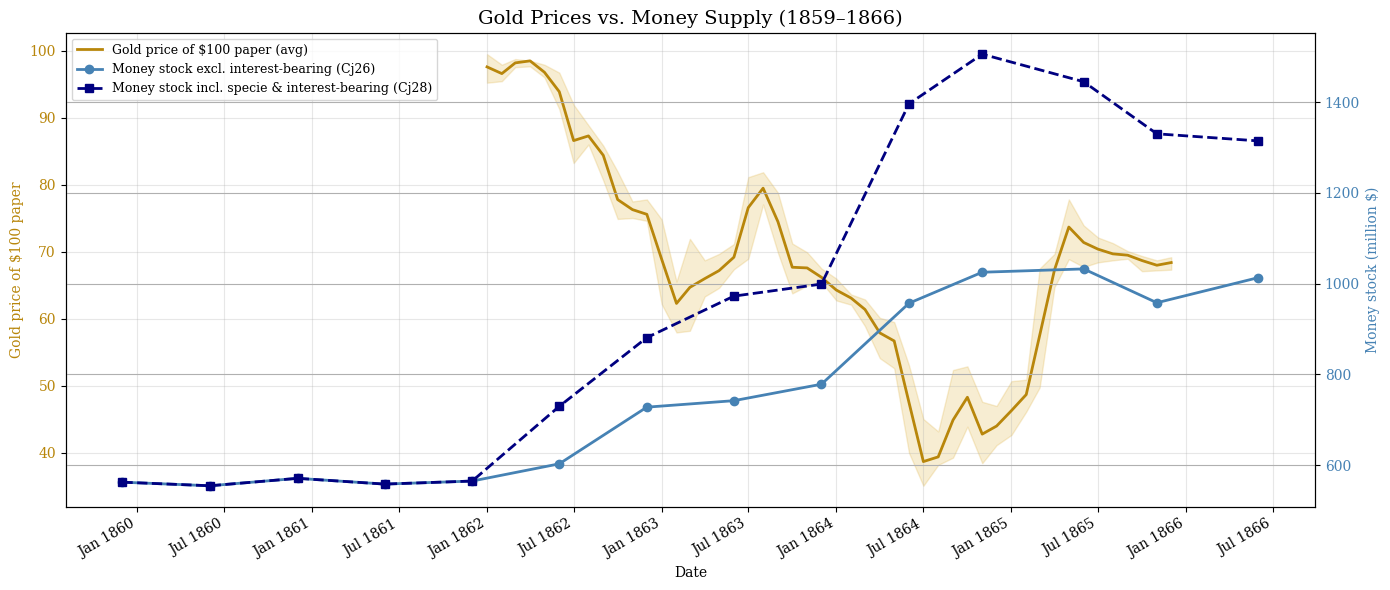

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load gold prices (monthly)
gold = pd.read_csv("data/mitchell_table1_gold_prices_1862_1865.csv", comment="#")
gold["date"] = pd.to_datetime(gold["year"].astype(str) + "-" + gold["month"], format="%Y-%B")

# Load money stock (semi-annual)
money = pd.read_csv("data/Cj26-41_money_stock_1859_1866.csv", comment="#")
month_map = {"Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4, "May": 5, "Jun": 6,
             "Jul": 7, "Aug": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12}
money["date"] = pd.to_datetime(
    money["Year"].astype(str) + "-" + money["Month"].map(month_map).astype(str),
    format="%Y-%m"
)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Gold prices on left axis
ax1.fill_between(gold["date"], gold["lowest"], gold["highest"], alpha=0.2, color="goldenrod")
ax1.plot(gold["date"], gold["average"], color="darkgoldenrod", linewidth=2, label="Gold price of $100 paper (avg)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Gold price of $100 paper", color="darkgoldenrod")
ax1.tick_params(axis="y", labelcolor="darkgoldenrod")

# Money supply on right axis
ax2 = ax1.twinx()
ax2.plot(money["date"], money["Cj26"], color="steelblue", linewidth=2, marker="o",
         label="Money stock excl. interest-bearing (Cj26)")
ax2.plot(money["date"], money["Cj28"], color="navy", linewidth=2, marker="s", linestyle="--",
         label="Money stock incl. specie & interest-bearing (Cj28)")
ax2.set_ylabel("Money stock (million $)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

ax1.set_title("Gold Prices vs. Money Supply (1859–1866)", fontsize=14)
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()